In [30]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json

# 仿真数据后处理

In [31]:
folder = "..\\result\\simulation_validation_darcy_water_1.0"

In [32]:
def get_all_json_filename(path):
    filenames = []
    for filename in os.listdir(path):
        if filename.endswith(".json"):
            filenames.append(os.path.join(path,filename))
    return filenames

In [33]:
jsonFiles = get_all_json_filename(folder)
t = []
var_names = ["moment"]
variables = []
for var in var_names:
    variables.append([])
for jsonFile in jsonFiles:
    with open(jsonFile,"rb") as f:
        data = json.load(f)
        t.append(data["time"])
        i = 0
        for var in var_names:
            
                variables[i].append(data[var])
     
                i += 1
sorted_indices = np.argsort(t)
t = np.array(t)
t = t[sorted_indices]
i=0
for var in var_names:
    variables[i] = np.array(variables[i]) 
    variables[i] = variables[i][sorted_indices]
    i += 1


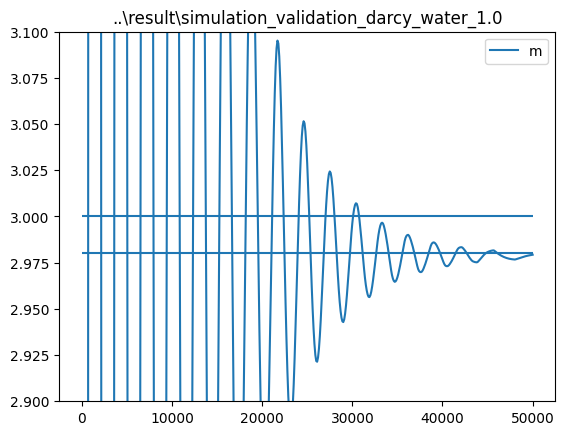

In [35]:
from numpy import inf


plt.plot(t,variables[0])
plt.legend(var_names[0])
plt.title(folder)
plt.hlines([298*0.01,300*0.01],0,50000)
plt.ylim(2.9,3.1)
plt.show()